In [ ]:
# Install minisom for implementing SOM
!pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13083 sha256=35e6d942dd7582f154c7503a5745c3d312c0c565cba2c86f4a923574af4f0837
  Stored in directory: /root/.cache/pip/wheels/84/35/b8/48b06bd8cae7187916c28a29c6daa9e0ff610647a2dfa62b97
Successfully built minisom


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from minisom import MiniSom

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

bank_marketing = fetch_ucirepo(id=222)

data = bank_marketing.data.features.copy()
targets = bank_marketing.data.targets.copy()

df = data.copy()
df['y'] = targets

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Drop target for clustering
X = df.drop(columns=['y'])

# Identify columns
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

# Pipelines
num_pipe = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

X_proc = preprocess.fit_transform(X)

print("Processed Shape:", X_proc.shape)

Processed Shape: (45211, 51)


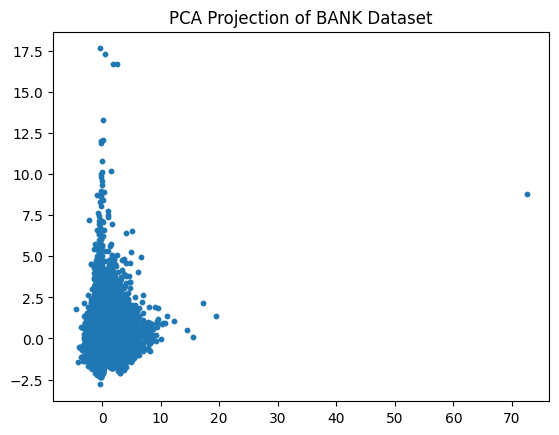

In [ ]:
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_proc)

plt.scatter(X_vis[:,0], X_vis[:,1], s=10)
plt.title("PCA Projection of BANK Dataset")
plt.show()

In [ ]:
k = 5

kmeans = KMeans(n_clusters=k, random_state=42)
k_labels = kmeans.fit_predict(X_proc)

gmm = GaussianMixture(n_components=k, random_state=42)
g_labels = gmm.fit_predict(X_proc)

print("KMeans Silhouette:", silhouette_score(X_proc, k_labels))
print("GMM Silhouette:", silhouette_score(X_proc, g_labels))
print("GMM Log Likelihood:", gmm.score(X_proc))

KMeans Silhouette: 0.0917941738076889
GMM Silhouette: 0.025447610319183096
GMM Log Likelihood: 112.81735958084337


In [ ]:
probs = gmm.predict_proba(X_proc[:5])
pd.DataFrame(probs, columns=[f"C{i}" for i in range(k)])

,C0,C1,C2,C3,C4
0,0.999988,1.164480e-05,7.528974e-44,1.382343e-23,0.0
1,0.999984,1.552043e-05,1.578479e-45,1.829513e-25,0.0
2,1.000000,1.048452e-10,3.160663e-52,1.473443e-40,0.0
3,0.999859,1.409281e-04,4.505755e-42,9.442090e-27,0.0
4,0.000000,0.000000e+00,9.514392e-26,1.000000e+00,0.0


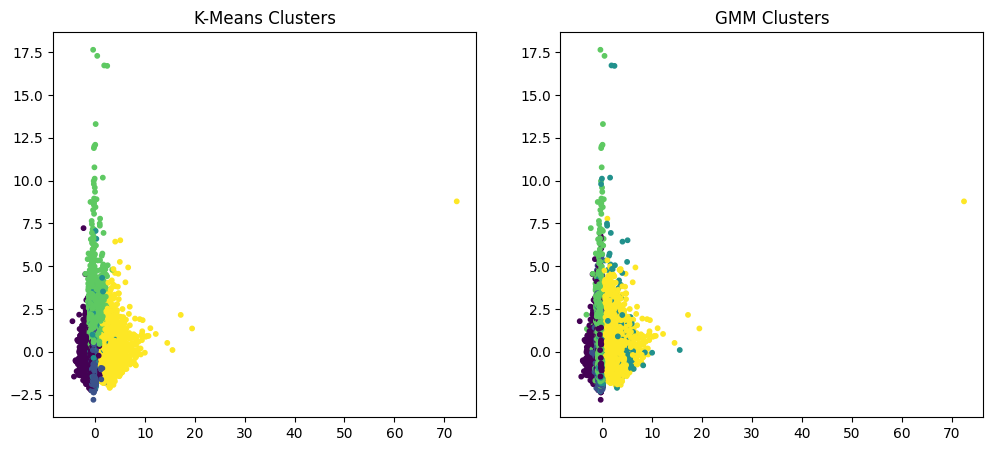

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_vis[:,0], X_vis[:,1], c=k_labels, s=10)
plt.title("K-Means Clusters")

plt.subplot(1,2,2)
plt.scatter(X_vis[:,0], X_vis[:,1], c=g_labels, s=10)
plt.title("GMM Clusters")

plt.show()

In [ ]:
types = ['full','tied','diag','spherical']

for t in types:
    model = GaussianMixture(n_components=k, covariance_type=t)
    labels = model.fit_predict(X_proc)
    print(t, "Silhouette:", silhouette_score(X_proc, labels))

full Silhouette: 0.016696342031610596
tied Silhouette: 0.06524634196294535
diag Silhouette: 0.044670946350295594
spherical Silhouette: 0.06338226120369173


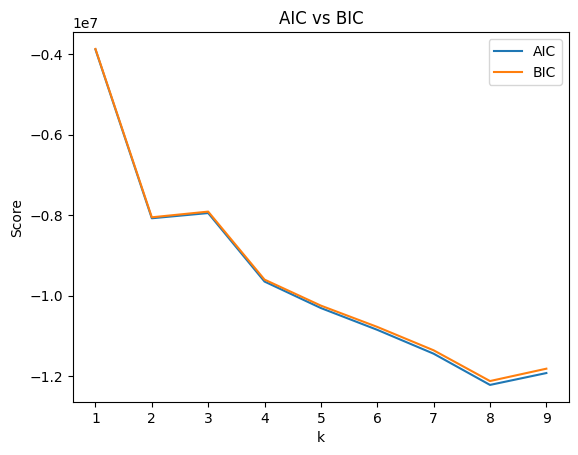

In [ ]:
ks = range(1,10)
aic, bic = [], []

for k in ks:
    model = GaussianMixture(n_components=k)
    model.fit(X_proc)
    aic.append(model.aic(X_proc))
    bic.append(model.bic(X_proc))

plt.plot(ks, aic, label="AIC")
plt.plot(ks, bic, label="BIC")
plt.legend()
plt.xlabel("k")
plt.ylabel("Score")
plt.title("AIC vs BIC")
plt.show()

- K-Means- Hard clustering (each point → one cluster)
- GMM- Soft clustering (probabilities)
   
  2 GMM IS BETTER BECAUSE-:
- Overlapping clusters
- Elliptical shapes
- Different densities

  3 kMEANS FAILS REASON
- Assumes spherical clusters
- Distance-based only

TASK 2

In [ ]:
from minisom import MiniSom

som = MiniSom(10, 10, X_proc.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(X_proc)
som.train_random(X_proc, 3000)

print("Quantization Error:", som.quantization_error(X_proc))

Quantization Error: 2.8508046413554395


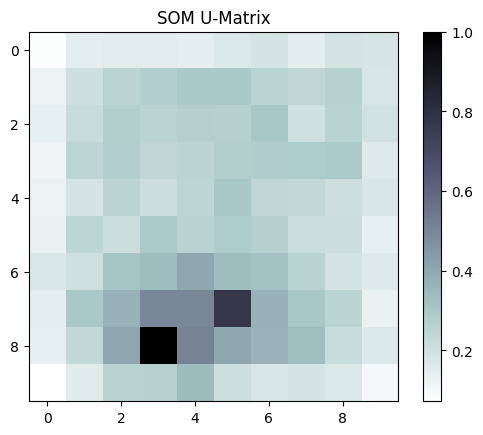

In [ ]:
plt.imshow(som.distance_map().T, cmap='bone_r')
plt.colorbar()
plt.title("SOM U-Matrix")
plt.show()

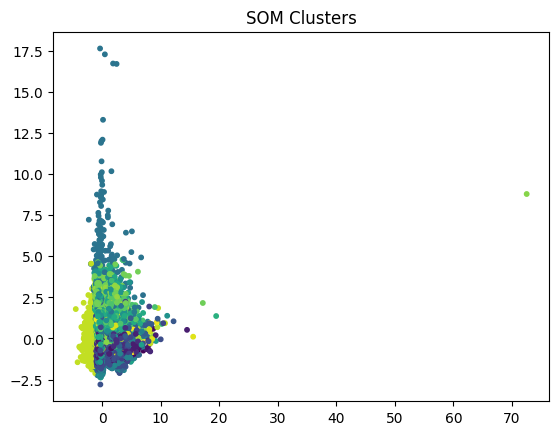

In [ ]:
labels = []

for x in X_proc:
    w = som.winner(x)
    labels.append(w[0]*10 + w[1])

plt.scatter(X_vis[:,0], X_vis[:,1], c=labels, s=10)
plt.title("SOM Clusters")
plt.show()

 SOM vs PCA

- SOM preserves topology (neighborhood)
- PCA preserves variance

 Key Difference
- PCA → linear
- SOM → nonlinear

 Conclusion
SOM is better for visualization of clusters,
PCA is better for dimensionality reduction.